In [22]:
#importing training data and shuffling it

import pickle as pkl
import os

all_data = []
duration = 180.0  # Duration used when collecting data

for left_std in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    for right_std in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
        for servo_std in [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]:
            filename = f"noisy_training_data_180_0_05/noisy_spiral_{left_std}_{right_std}_{servo_std}_{duration}s.pkl"
            
            # Check if file exists before loading
            if os.path.exists(filename):
                try:
                    data = pkl.load(open(filename, "rb"))
                    all_data.extend(data)
                    print(f"Loaded {len(data)} tuples from {filename}")
                except Exception as e:
                    print(f"Error loading {filename}: {e}")
            else:
                print(f"File not found: {filename}")

print(f"\nTotal data tuples collected: {len(all_data)}")

import numpy as np
import random

# Shuffle the list - this is the easiest way!
# Shuffling a list is simpler than shuffling tensors
random.shuffle(all_data)

# Or using numpy (same result):
# np.random.shuffle(all_data)

print(f"Shuffled {len(all_data)} data tuples")
print(f"First tuple: state shape={all_data[0][0].shape}, action shape={all_data[0][1].shape}, next_state shape={all_data[0][2].shape}")

Loaded 3600 tuples from noisy_training_data_180_0_05/noisy_spiral_0.0_0.0_0.0_180.0s.pkl
Loaded 3600 tuples from noisy_training_data_180_0_05/noisy_spiral_0.0_0.0_0.3_180.0s.pkl
Loaded 3600 tuples from noisy_training_data_180_0_05/noisy_spiral_0.0_0.0_0.6_180.0s.pkl
Loaded 3600 tuples from noisy_training_data_180_0_05/noisy_spiral_0.0_0.0_0.9_180.0s.pkl
Loaded 3600 tuples from noisy_training_data_180_0_05/noisy_spiral_0.0_0.0_1.2_180.0s.pkl
Loaded 3600 tuples from noisy_training_data_180_0_05/noisy_spiral_0.0_0.0_1.5_180.0s.pkl
Loaded 3600 tuples from noisy_training_data_180_0_05/noisy_spiral_0.0_0.1_0.0_180.0s.pkl
Loaded 3600 tuples from noisy_training_data_180_0_05/noisy_spiral_0.0_0.1_0.3_180.0s.pkl
Loaded 3600 tuples from noisy_training_data_180_0_05/noisy_spiral_0.0_0.1_0.6_180.0s.pkl
Loaded 3600 tuples from noisy_training_data_180_0_05/noisy_spiral_0.0_0.1_0.9_180.0s.pkl
Loaded 3600 tuples from noisy_training_data_180_0_05/noisy_spiral_0.0_0.1_1.2_180.0s.pkl
Loaded 3600 tuples fr

In [ ]:
#saving the training data

# training_data = all_data[0:350000]
# print(len(training_data))
file_name = "k_training_data_0_05.pkl"
with open(file_name, "wb") as f:
    pkl.dump(training_data, f)

In [ ]:
# loading the training data

import pickle as pkl

file_name = "250k_training_data_0_05.pkl"
with open(file_name, "rb") as f:
    training_data = pkl.load(f)

training_data = training_data[:48500]

In [23]:
# Convert training_data format (state, action, next_state) to batch format

import matplotlib.pyplot as plt
import numpy as np
import torch

# ----- Offline training (supervised next-step regression) -----
batch_x_list = []
batch_y_list = []


for state, action, next_state in training_data:
    obs_tensor = torch.from_numpy(state).float()
    action_tensor = torch.from_numpy(action).float()
    next_obs_tensor = torch.from_numpy(next_state).float()
    
    batch_x_list.append(torch.cat([obs_tensor, action_tensor], dim=-1))
    batch_y_list.append(next_obs_tensor)

# Convert to tensors with correct dimensions
batch_x = torch.stack(batch_x_list, dim=0)  # shape: [B, 12] (9 state + 3 action)
batch_y = torch.stack(batch_y_list, dim=0)


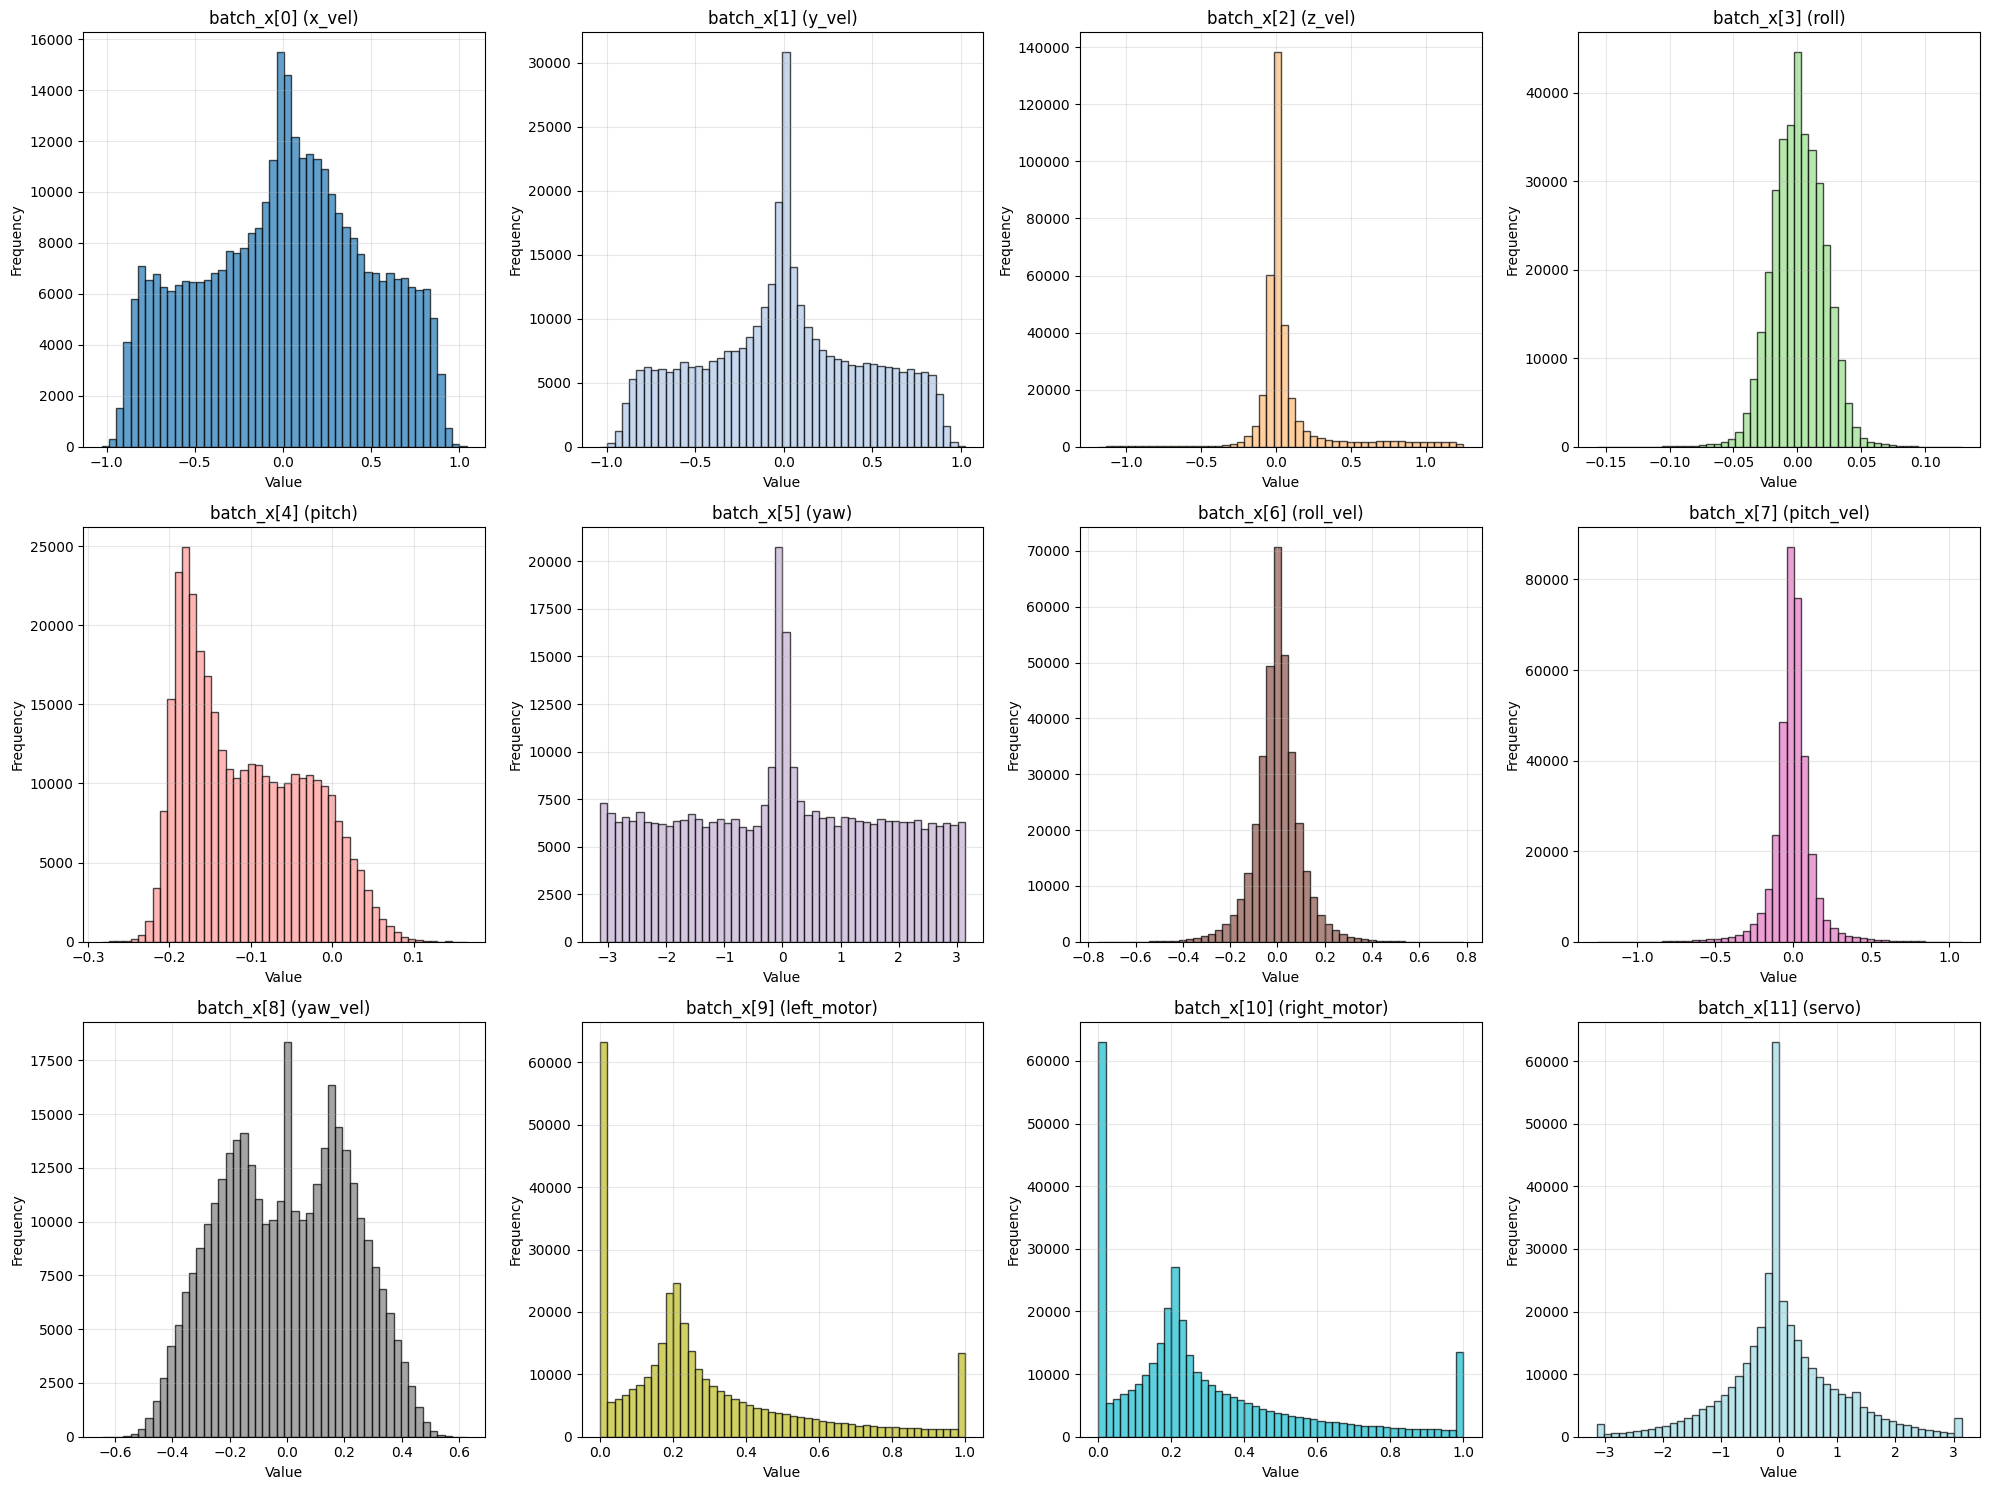

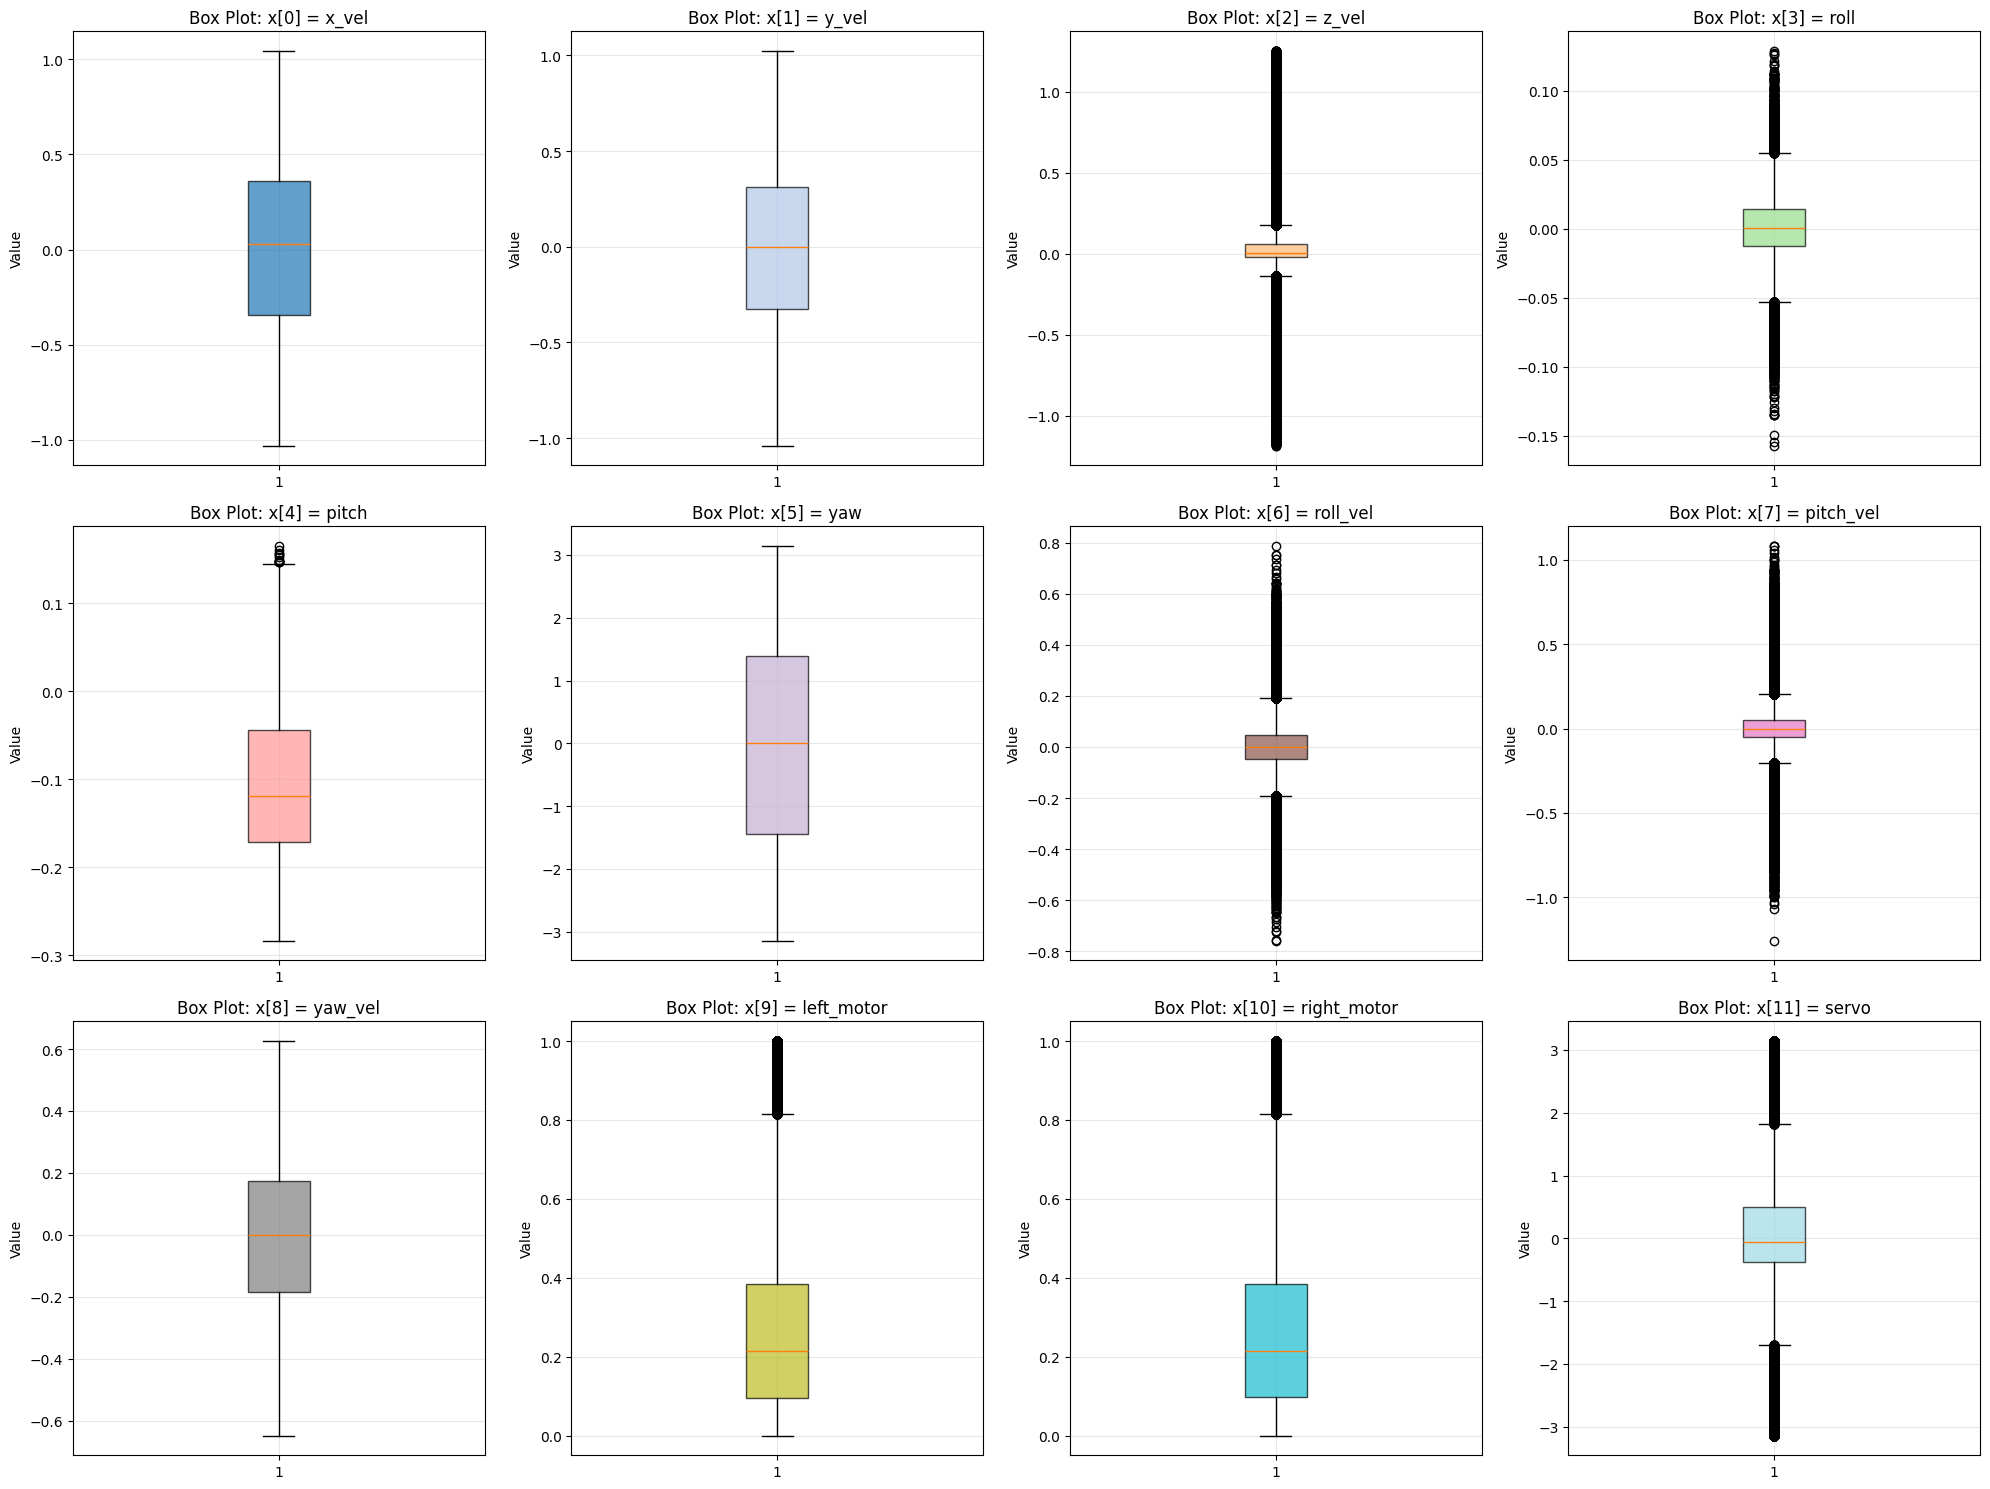

Statistics for batch_x features:
x[0] = x_vel - Mean: 0.0116, Std: 0.4709, Min: -1.0292, Max: 1.0425
x[1] = y_vel - Mean: -0.0053, Std: 0.4570, Min: -1.0385, Max: 1.0224
x[2] = z_vel - Mean: 0.0746, Std: 0.2595, Min: -1.1847, Max: 1.2514
x[3] = roll - Mean: 0.0010, Std: 0.0197, Min: -0.1569, Max: 0.1287
x[4] = pitch - Mean: -0.1059, Std: 0.0743, Min: -0.2835, Max: 0.1651
x[5] = yaw - Mean: -0.0190, Std: 1.7333, Min: -3.1416, Max: 3.1416
x[6] = roll_vel - Mean: -0.0003, Std: 0.0970, Min: -0.7573, Max: 0.7862
x[7] = pitch_vel - Mean: -0.0017, Std: 0.1259, Min: -1.2573, Max: 1.0819
x[8] = yaw_vel - Mean: -0.0030, Std: 0.2222, Min: -0.6473, Max: 0.6256
x[9] = left_motor - Mean: 0.2820, Std: 0.2620, Min: 0.0000, Max: 1.0000
x[10] = right_motor - Mean: 0.2814, Std: 0.2608, Min: 0.0000, Max: 1.0000
x[11] = servo - Mean: 0.0522, Std: 0.9809, Min: -3.1416, Max: 3.1416


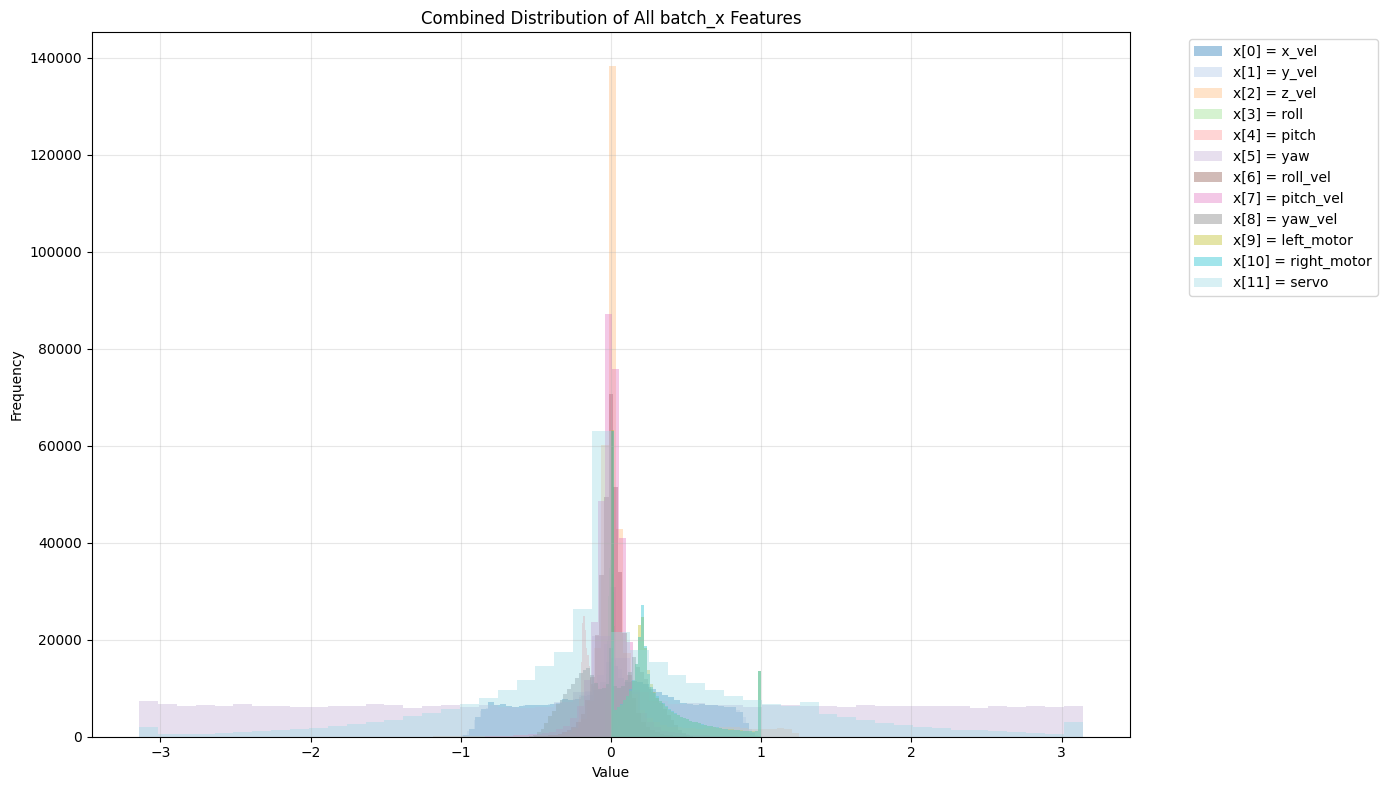

In [24]:
# Plot distributions of all features in batch_x

# Get number of features
num_features = batch_x.shape[1]

# Feature names (9 state features + 3 action features)
feature_names = [
    'x_vel', 'y_vel', 'z_vel',  # velocities
    'roll', 'pitch', 'yaw',     # angles (or angular velocities)
    'roll_vel', 'pitch_vel', 'yaw_vel',  # angular velocities
    'left_motor', 'right_motor', 'servo'  # actions
]

# Extract all features for plotting
features = [batch_x[:, i].cpu().numpy() for i in range(num_features)]

# Create subplots for histograms (3 rows x 4 columns for 12 features)
n_cols = 4
n_rows = (num_features + n_cols - 1) // n_cols  # Ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))

# Flatten axes for easier indexing
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

# Plot histograms for all features
colors = plt.cm.tab20(np.linspace(0, 1, num_features))
for i in range(num_features):
    ax = axes_flat[i]
    ax.hist(features[i], bins=50, alpha=0.7, color=colors[i], edgecolor='black')
    ax.set_title(f'batch_x[{i}] ({feature_names[i] if i < len(feature_names) else f"feature_{i}"})')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for i in range(num_features, len(axes_flat)):
    axes_flat[i].axis('off')

plt.tight_layout()
plt.show()

# Create subplots for box plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

# Plot box plots for all features
for i in range(num_features):
    ax = axes_flat[i]
    feat_name = feature_names[i] if i < len(feature_names) else f"feature_{i}"
    bp = ax.boxplot(features[i], patch_artist=True, 
                    boxprops=dict(facecolor=colors[i], alpha=0.7))
    ax.set_title(f'Box Plot: x[{i}] = {feat_name}')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for i in range(num_features, len(axes_flat)):
    axes_flat[i].axis('off')

plt.tight_layout()
plt.show()

# Print statistics for all features
print("Statistics for batch_x features:")
for i in range(num_features):
    feat_name = feature_names[i] if i < len(feature_names) else f"feature_{i}"
    print(f"x[{i}] = {feat_name} - Mean: {np.mean(features[i]):.4f}, "
          f"Std: {np.std(features[i]):.4f}, Min: {np.min(features[i]):.4f}, "
          f"Max: {np.max(features[i]):.4f}")

# Combined distribution plot for all features
plt.figure(figsize=(14, 8))
for i in range(num_features):
    feat_name = feature_names[i] if i < len(feature_names) else f"feature_{i}"
    plt.hist(features[i], bins=50, alpha=0.4, 
             label=f'x[{i}] = {feat_name}', color=colors[i])
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Combined Distribution of All batch_x Features')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
import torch
from saviolo_et_al_mlp import DiscreteQuadDynamicsNN


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sav_model = DiscreteQuadDynamicsNN()
sav_model.to(device)


DiscreteQuadDynamicsNN(
  (fc1): Linear(in_features=12, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=9, bias=True)
  (activation): ELU(alpha=1.0)
)

In [15]:
# Prepare training tensors from training_data (state, action, next_state)
import torch

batch_x_list = []
batch_y_list = []
for state, action, next_state in training_data:
    obs_tensor = torch.from_numpy(state).float()
    action_tensor = torch.from_numpy(action).float()
    next_obs_tensor = torch.from_numpy(next_state).float()
    batch_x_list.append(torch.cat([obs_tensor, action_tensor], dim=-1))
    batch_y_list.append(next_obs_tensor)

batch_x = torch.stack(batch_x_list, dim=0)  # [B, 12]
batch_y = torch.stack(batch_y_list, dim=0)  # [B, 9]

# Move to device
batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

# Compute dataset statistics
x_mean, x_std = batch_x.mean(dim=0), batch_x.std(dim=0)
y_mean, y_std = batch_y.mean(dim=0), batch_y.std(dim=0)
print("x_mean", x_mean, "x_std", x_std, "y_mean", y_mean, "y_std", y_std)

# Avoid division by zero
x_std = x_std.clamp_min(1e-8)
y_std = y_std.clamp_min(1e-8)

# Attach stats if model is available
if 'sav_model' in globals():
    sav_model.attach_stats(x_mean, x_std, y_mean, y_std)

# Normalize
batch_x = (batch_x - x_mean) / x_std
batch_y = (batch_y - y_mean) / y_std

# Split into train/val
N = batch_x.shape[0]
perm = torch.randperm(N, device=batch_x.device)
N_val = max(1, int(0.1 * N))
val_idx = perm[:N_val]
train_idx = perm[N_val:]

batch_x_train = batch_x[train_idx]
batch_y_train = batch_y[train_idx]
batch_x_val   = batch_x[val_idx]
batch_y_val   = batch_y[val_idx]

print("Train set:", batch_x_train.shape, batch_y_train.shape)
print("Val set:", batch_x_val.shape, batch_y_val.shape)


x_mean tensor([ 1.1648e-02, -5.3006e-03,  7.4551e-02,  1.0022e-03, -1.0587e-01,
        -1.9004e-02, -2.6582e-04, -1.6923e-03, -2.9514e-03,  2.8195e-01,
         2.8140e-01,  5.2204e-02], device='cuda:0') x_std tensor([0.4709, 0.4570, 0.2595, 0.0197, 0.0743, 1.7333, 0.0970, 0.1259, 0.2222,
        0.2620, 0.2608, 0.9809], device='cuda:0') y_mean tensor([ 0.0116, -0.0053,  0.0746,  0.0010, -0.1059, -0.0190, -0.0003, -0.0017,
        -0.0030], device='cuda:0') y_std tensor([0.4709, 0.4570, 0.2595, 0.0197, 0.0743, 1.7333, 0.0970, 0.1259, 0.2222],
       device='cuda:0')
Train set: torch.Size([315000, 12]) torch.Size([315000, 9])
Val set: torch.Size([35000, 12]) torch.Size([35000, 9])


In [16]:
# ----- Training -----
import torch

opt = torch.optim.Adam(sav_model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=25, min_lr=1e-9, verbose=True
)

batch_size = 1024

def compute_validation_loss():
    sav_model.eval()
    with torch.no_grad():
        Nval = batch_x_val.shape[0]
        total, count = 0.0, 0
        for s in range(0, Nval, batch_size):
            e = min(s + batch_size, Nval)
            stats = sav_model.supervised_step(batch_x_val[s:e], batch_y_val[s:e], None)
            bsz = e - s
            total += stats["loss"] * bsz   # assume mean loss returned
            count += bsz
        return total / max(1, count)

print("Starting training...")
for epoch in range(200):  # paper reports ~20K epochs
    sav_model.train()

    # Shuffle train set
    Ntr = batch_x_train.shape[0]
    idx = torch.randperm(Ntr, device=batch_x_train.device)
    x_shuf = batch_x_train.index_select(0, idx)
    y_shuf = batch_y_train.index_select(0, idx)

    # Mini-batch training (NO tail drop + sample-weighted averaging)
    total_train, rpy_loss, lv_loss, w_loss, count_train = 0.0, 0.0, 0.0, 0.0, 0
    for s in range(0, Ntr, batch_size):
        e = min(s + batch_size, Ntr)
        stats = sav_model.supervised_step(x_shuf[s:e], y_shuf[s:e], opt)
        bsz = e - s
        total_train += stats["loss"] * bsz
        rpy_loss += stats.get("lq", 0.0) * bsz
        lv_loss += stats.get("lv", 0.0) * bsz
        w_loss  += stats.get("lw", 0.0) * bsz
        count_train += bsz
    avg_train_loss = total_train / max(1, count_train)
    avg_rpy_loss   = rpy_loss   / max(1, count_train)
    avg_lv_loss    = lv_loss    / max(1, count_train)
    avg_w_loss     = w_loss     / max(1, count_train)

    # Validation + scheduler
    val_loss = compute_validation_loss()
    scheduler.step(val_loss)

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | Train {avg_train_loss:.9f} | lv {avg_lv_loss:.9f} | w {avg_w_loss:.9f} | rpy {avg_rpy_loss:.9f} | Val {val_loss:.6f} | "
              f"LR {opt.param_groups[0]['lr']:.2e}")


c:\Users\ksubh\anaconda3\envs\agile_blimp_2\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training...
Epoch    0 | Train 0.180727967 | lv 0.057770995 | w 0.057161994 | rpy 0.065794978 | Val 0.010749 | LR 1.00e-03
Epoch   50 | Train 0.000099118 | lv 0.000023227 | w 0.000031708 | rpy 0.000044183 | Val 0.000099 | LR 1.00e-03
Epoch  100 | Train 0.000074853 | lv 0.000019666 | w 0.000022955 | rpy 0.000032232 | Val 0.000054 | LR 1.00e-03
Epoch  150 | Train 0.000035020 | lv 0.000010124 | w 0.000010470 | rpy 0.000014426 | Val 0.000035 | LR 5.00e-04


In [7]:
# Save trained model 
sav_model.save_model("trained_models/trained_model_noisy_spiral_0_05.pth")


In [14]:
# load the trained model
from saviolo_et_al_mlp import DiscreteQuadDynamicsNN 
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sav_model = DiscreteQuadDynamicsNN()
sav_model.load_model("trained_models/trained_model_noisy_spiral_0_05.pth")
sav_model.to(device)


c:\Users\ksubh\OneDrive\Documents\SwarmsLab_RL\agile-blimp\mochi-swarm-sim\saviolo_et_al_mlp.py:204: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch

DiscreteQuadDynamicsNN(
  (fc1): Linear(in_features=12, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=9, bias=True)
  (activation): ELU(alpha=1.0)
)

In [45]:
import numpy as np

# Helper to wrap angles to [-pi, pi]
def wrap_pi(angle_rad: float) -> float:
    return ((angle_rad + np.pi) % (2 * np.pi)) - np.pi

# Load and align real training data servo angle to simulator convention
# Real data: 0 = up, +pi = down
# Simulator: +pi/2 = up, -pi/2 = down
# Mapping: theta_sim = pi/2 - theta_real, then wrap to [-pi, pi]
with open('real_training_tuples_75K_0_05.pkl', 'rb') as f:
    real_training_data = pickle.load(f)

aligned_real_training_data = []
for s, a, s_next in real_training_data:
    theta_real = a[2]
    theta_sim = wrap_pi(np.pi / 2 - theta_real)
    a_aligned = np.array([a[0], a[1], theta_sim], dtype=np.float32)
    aligned_real_training_data.append((s, a_aligned, s_next))

# Stats before/after alignment for sanity check
servo_real = [a[2] for _, a, _ in real_training_data]
servo_aligned = [a[2] for _, a, _ in aligned_real_training_data]
print("Real servo (rad)   min/max/mean:", np.min(servo_real), np.max(servo_real), np.mean(servo_real))
print("Real servo (deg)   min/max/mean:", np.rad2deg(np.min(servo_real)), np.rad2deg(np.max(servo_real)), np.rad2deg(np.mean(servo_real)))
print("Aligned servo (rad) min/max/mean:", np.min(servo_aligned), np.max(servo_aligned), np.mean(servo_aligned))
print("Aligned servo (deg) min/max/mean:", np.rad2deg(np.min(servo_aligned)), np.rad2deg(np.max(servo_aligned)), np.rad2deg(np.mean(servo_aligned)))

# Load simulator noisy training data (already in simulator convention)
with open('noisy_training_data_0_05/noisy_spiral_0.0_0.1_1.2_60.0s.pkl', 'rb') as f:
    sim_training_data = pickle.load(f)

servo_sim = [a[2] for _, a, _ in sim_training_data]
print("Sim servo (rad)     min/max/mean:", np.min(servo_sim), np.max(servo_sim), np.mean(servo_sim))
print("Sim servo (deg)     min/max/mean:", np.rad2deg(np.min(servo_sim)), np.rad2deg(np.max(servo_sim)), np.rad2deg(np.mean(servo_sim)))

Real servo (rad)   min/max/mean: 0.0 2.3169246 1.5887815
Real servo (deg)   min/max/mean: 0.0 132.74998 91.03047
Aligned servo (rad) min/max/mean: -0.7461283 1.5707963 -0.017985051
Aligned servo (deg) min/max/mean: -42.75 89.99999 -1.0304675
Sim servo (rad)     min/max/mean: -3.141592653589793 3.141592653589793 -0.14044522931781697
Sim servo (deg)     min/max/mean: -180.0 180.0 -8.046918892657926


In [ ]:
# Load validation data to Validate NN predictions for all states
import pickle
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use validation data from training_data (or load from file if needed)
# validation_data = training_data[-500:]  # Use last 500 samples
# Or load from saved file
# with open('noisy_training_data_0_05/noisy_spiral_0.5_0.2_0.9_60.0s.pkl', 'rb') as f:
#     all_training_data = pickle.load(f)
#     validation_data = all_training_data[200:1000]  # Use last 500 samples for validation

# with open('training_data_dupes/dupe_9_ag.pkl', 'rb') as f:
#     all_training_data = pickle.load(f)
#     print(len(all_training_data))
#     validation_data = all_training_data[3000:3600]  # Use last 500 samples for validation


validation_data = aligned_real_training_data[2500:3000]

dx_actual = []
dy_actual = []
dz_actual = []
droll_actual = []
dpitch_actual = []
dyaw_actual = []
roll_actual = []
pitch_actual = []
yaw_actual = []

dx_predicted = []
dy_predicted = []
dz_predicted = []
droll_predicted = []
dpitch_predicted = []
dyaw_predicted = []
roll_predicted = []
pitch_predicted = []
yaw_predicted = []

left_motor = []
right_motor = []
servo = []

time = 0
time_steps = []

for state, action, next_state in validation_data:
    dummy_model_state = {}
    dummy_model_state["obs"] = torch.tensor(state).to(device).float().unsqueeze(0)
    action_tensor = torch.tensor(action).to(device).float().unsqueeze(0)
    next_observs_nn, _, _, next_dummy_model_state_nn = sav_model.sample(action_tensor, dummy_model_state)
    
    # Extract actual values from next_state (9-dim: [x_vel, y_vel, z_vel, roll, pitch, yaw, roll_vel, pitch_vel, yaw_vel])
    dx_actual.append(next_state[0])
    dy_actual.append(next_state[1])
    dz_actual.append(next_state[2])
    roll_actual.append(next_state[3])
    pitch_actual.append(next_state[4])
    yaw_actual.append(next_state[5])
    droll_actual.append(next_state[6])
    dpitch_actual.append(next_state[7])
    dyaw_actual.append(next_state[8])
    
    # Extract predicted values (model output is also 9-dim in same order)
    dx_predicted.append(next_observs_nn[0, 0].item())
    dy_predicted.append(next_observs_nn[0, 1].item())
    dz_predicted.append(next_observs_nn[0, 2].item())
    roll_predicted.append(next_observs_nn[0, 3].item())
    pitch_predicted.append(next_observs_nn[0, 4].item())
    yaw_predicted.append(next_observs_nn[0, 5].item())
    droll_predicted.append(next_observs_nn[0, 6].item())
    dpitch_predicted.append(next_observs_nn[0, 7].item())
    dyaw_predicted.append(next_observs_nn[0, 8].item())
    
    # Extract actions (3-dim: [left_motor, right_motor, servo])
    left_motor.append(action[0])
    right_motor.append(action[1])
    servo.append(action[2])
    
    time_steps.append(time)
    time += 0.01  # Assuming 0.05s timestep (adjust if different)



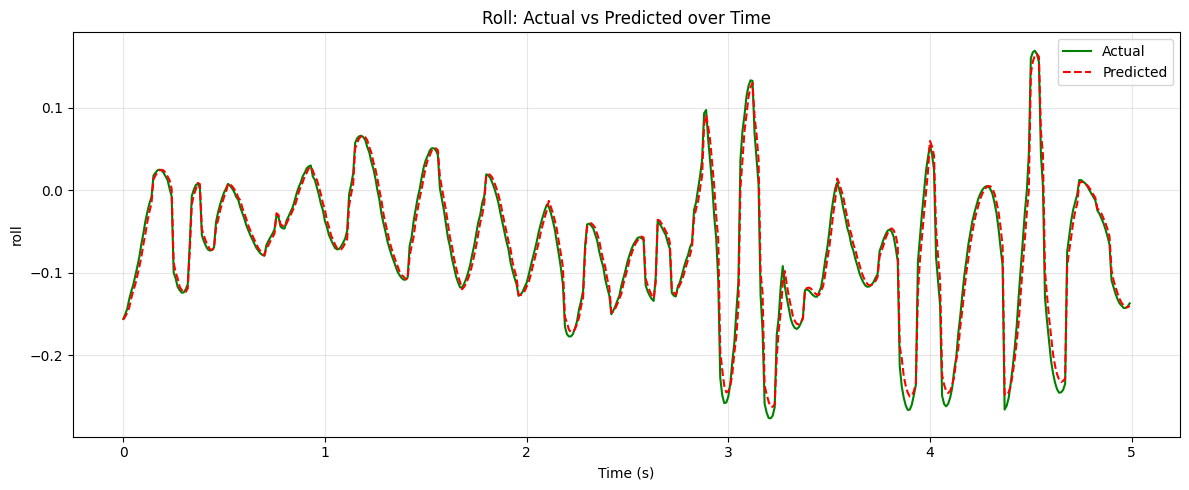

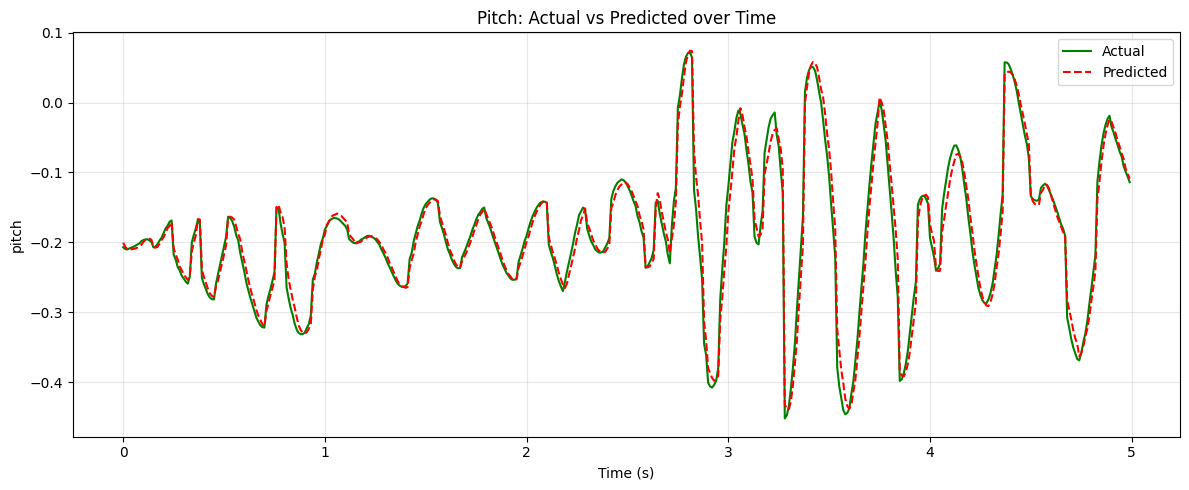

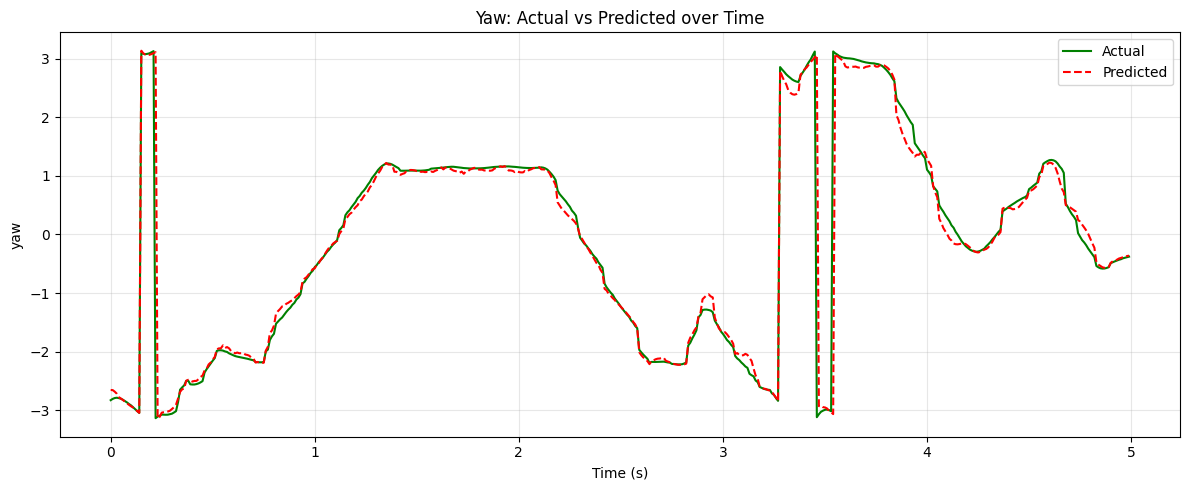

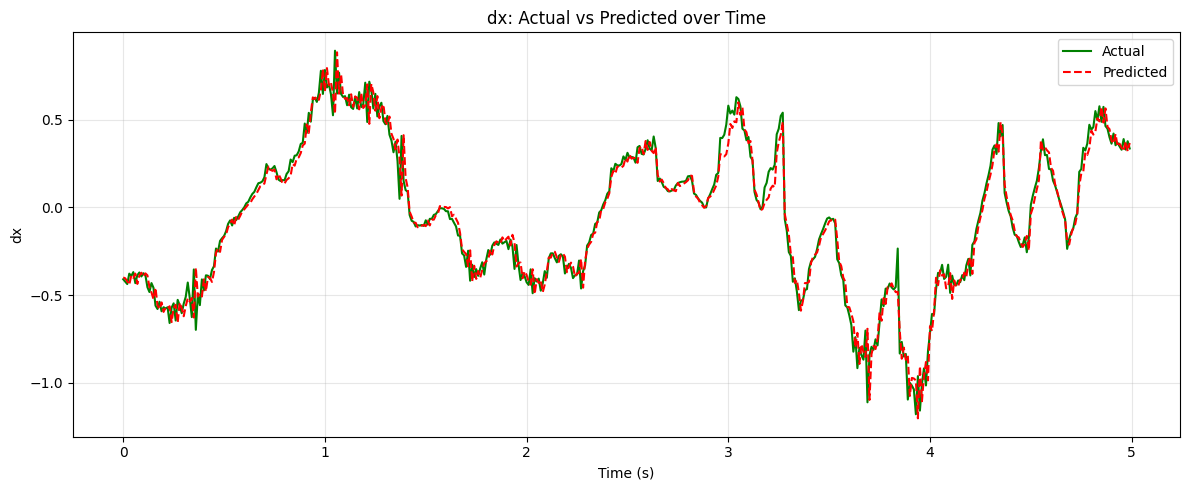

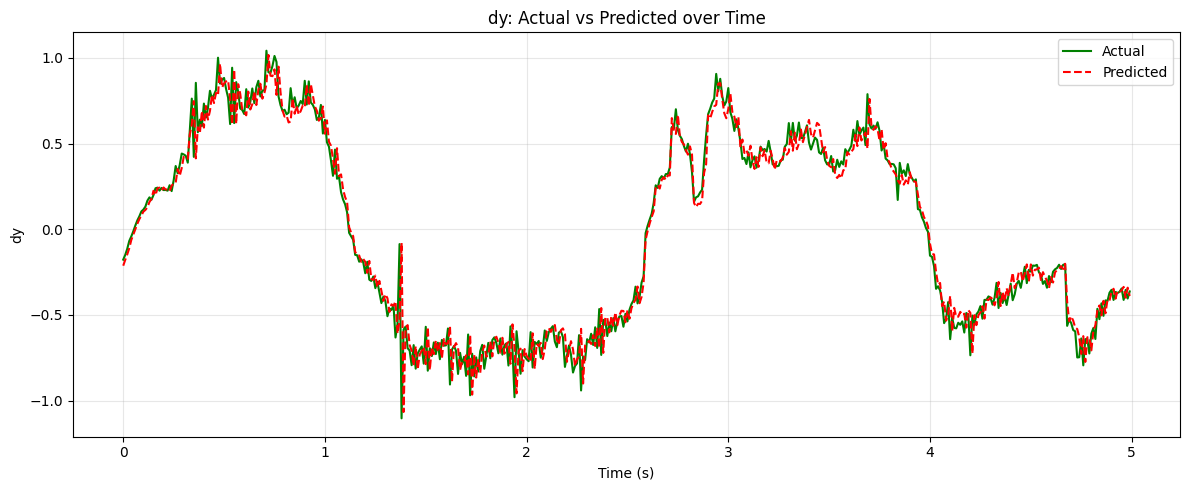

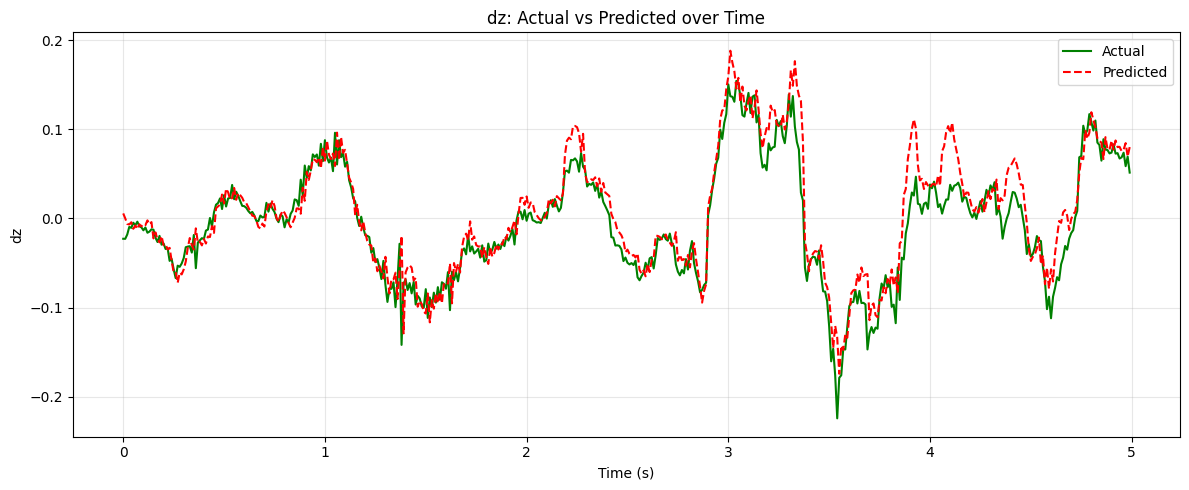

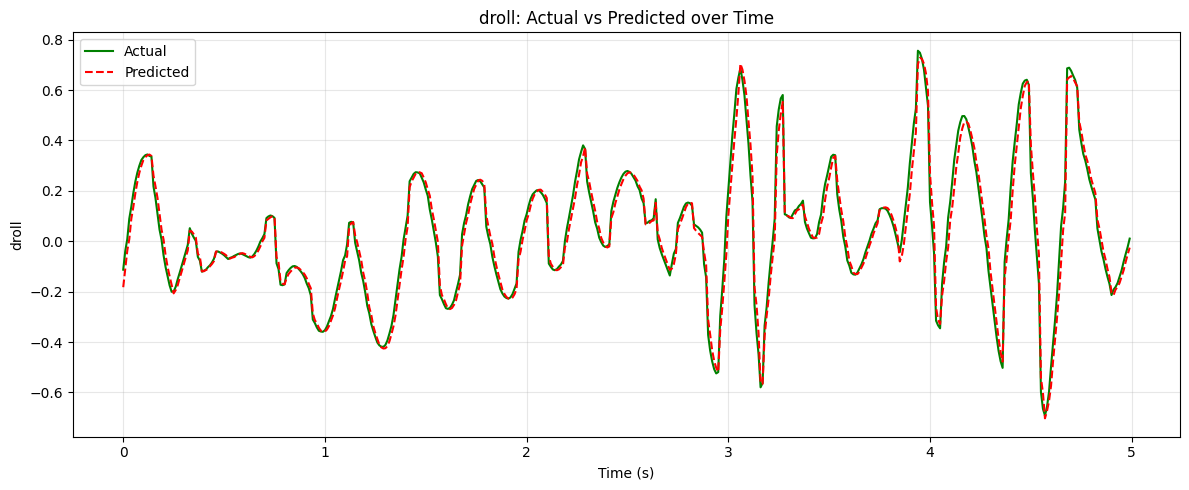

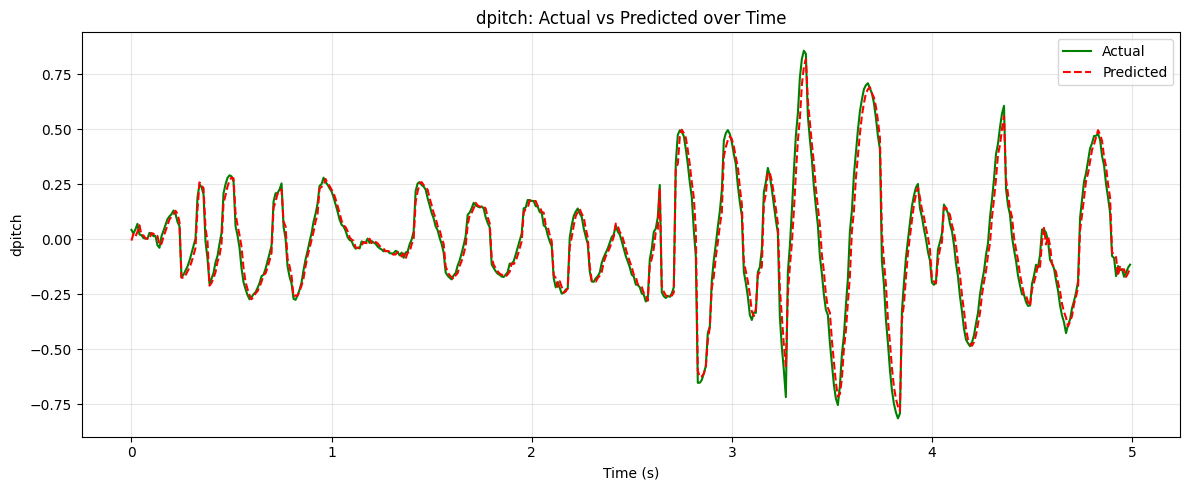

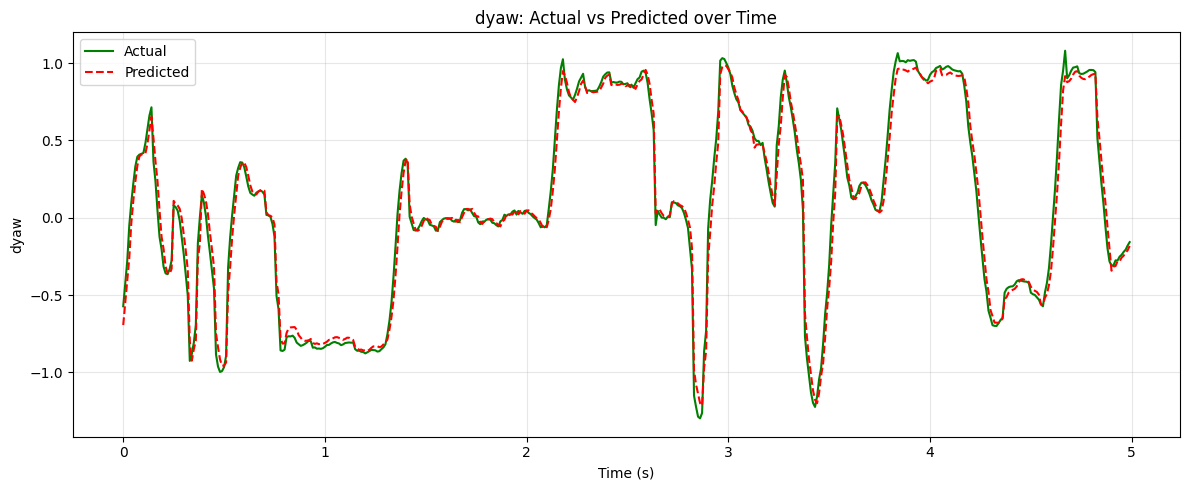

In [47]:
# Utility: plot actual vs predicted observation over time
import matplotlib.pyplot as plt

def plot_observation_vs_time(time_steps, actual_series, predicted_series, ylabel="obs", title="Observation vs Time"):
    """
    Plots actual (ground-truth) observation and predicted observation vs time.

    Args:
        time_steps (Sequence[float]): time values (s)
        actual_series (Sequence[float]): ground-truth observation values
        predicted_series (Sequence[float]): model-predicted observation values
        ylabel (str): y-axis label for the observation name
        title (str): plot title
    """
    plt.figure(figsize=(12, 5))
    plt.plot(time_steps, actual_series, 'g-', linewidth=1.5, label='Actual')
    plt.plot(time_steps, predicted_series, 'r--', linewidth=1.5, label='Predicted')
    plt.xlabel('Time (s)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage (uncomment and adapt lists you already computed):
plot_observation_vs_time(time_steps, roll_actual, roll_predicted, ylabel='roll', title='Roll: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, pitch_actual, pitch_predicted, ylabel='pitch', title='Pitch: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, yaw_actual, yaw_predicted, ylabel='yaw', title='Yaw: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, dx_actual, dx_predicted, ylabel='dx', title='dx: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, dy_actual, dy_predicted, ylabel='dy', title='dy: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, dz_actual, dz_predicted, ylabel='dz', title='dz: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, droll_actual, droll_predicted, ylabel='droll', title='droll: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, dpitch_actual, dpitch_predicted, ylabel='dpitch', title='dpitch: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, dyaw_actual, dyaw_predicted, ylabel='dyaw', title='dyaw: Actual vs Predicted over Time')




In [ ]:
import numpy as np

# Compute RMS error per state dimension between real and predicted trajectories
# actual_dict and pred_dict are dicts mapping names -> 1D arrays/lists of values
# e.g., actual_dict = {
#   'dx': dx_actual, 'dy': dy_actual, ..., 'yaw_vel': dyaw_actual
# }
# and similarly for pred_dict.

def compute_rms_errors(actual_dict, pred_dict):
    """Compute RMS error for each state dimension.

    Args:
        actual_dict (dict[str, Sequence[float]]): ground-truth series
        pred_dict   (dict[str, Sequence[float]]): predicted series

    Returns:
        dict[str, float]: mapping from name -> RMS error
    """
    rms_errors = {}
    for key in actual_dict.keys():
        a = np.asarray(actual_dict[key], dtype=np.float64)
        p = np.asarray(pred_dict[key], dtype=np.float64)
        if a.shape != p.shape:
            raise ValueError(f"Shape mismatch for {key}: actual {a.shape}, pred {p.shape}")
        err = a - p
        rms = np.sqrt(np.mean(err**2))
        rms_errors[key] = rms

    # Pretty-print
    print("RMS errors (per state dimension):")
    for k, v in rms_errors.items():
        print(f"  {k:10s}: {v:.6f}")

    return rms_errors

# Example usage after running the validation loop above:
# actual = {
#     'dx': dx_actual,
#     'dy': dy_actual,
#     'dz': dz_actual,
#     'roll': roll_actual,
#     'pitch': pitch_actual,
#     'yaw': yaw_actual,
#     'droll': droll_actual,
#     'dpitch': dpitch_actual,
#     'dyaw': dyaw_actual,
# }
# pred = {
#     'dx': dx_predicted,
#     'dy': dy_predicted,
#     'dz': dz_predicted,
#     'roll': roll_predicted,
#     'pitch': pitch_predicted,
#     'yaw': yaw_predicted,
#     'droll': droll_predicted,
#     'dpitch': dpitch_predicted,
#     'dyaw': dyaw_predicted,
# }
# rms = compute_rms_errors(actual, pred)
